In [7]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.naive_bayes import CategoricalNB, GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [8]:
df = pd.read_csv('adult.csv', header=None, sep=r',\s*')

In [9]:
df.shape

(32562, 15)

In [10]:
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,"""age""","""workclass""","""fnlwgt""","""education""","""education.num""","""marital.status""","""occupation""","""relationship""","""race""","""sex""","""capital.gain""","""capital.loss""","""hours.per.week""","""native.country""","""income"""
1,90,"""?""",77053,"""HS-grad""",9,"""Widowed""","""?""","""Not-in-family""","""White""","""Female""",0,4356,40,"""United-States""","""<=50K"""
2,82,"""Private""",132870,"""HS-grad""",9,"""Widowed""","""Exec-managerial""","""Not-in-family""","""White""","""Female""",0,4356,18,"""United-States""","""<=50K"""
3,66,"""?""",186061,"""Some-college""",10,"""Widowed""","""?""","""Unmarried""","""Black""","""Female""",0,4356,40,"""United-States""","""<=50K"""
4,54,"""Private""",140359,"""7th-8th""",4,"""Divorced""","""Machine-op-inspct""","""Unmarried""","""White""","""Female""",0,3900,40,"""United-States""","""<=50K"""


In [13]:
col_names = ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship',
             'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']

df.columns = col_names
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income'],
      dtype='object')

In [12]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,"""age""","""workclass""","""fnlwgt""","""education""","""education.num""","""marital.status""","""occupation""","""relationship""","""race""","""sex""","""capital.gain""","""capital.loss""","""hours.per.week""","""native.country""","""income"""
1,90,"""?""",77053,"""HS-grad""",9,"""Widowed""","""?""","""Not-in-family""","""White""","""Female""",0,4356,40,"""United-States""","""<=50K"""
2,82,"""Private""",132870,"""HS-grad""",9,"""Widowed""","""Exec-managerial""","""Not-in-family""","""White""","""Female""",0,4356,18,"""United-States""","""<=50K"""
3,66,"""?""",186061,"""Some-college""",10,"""Widowed""","""?""","""Unmarried""","""Black""","""Female""",0,4356,40,"""United-States""","""<=50K"""
4,54,"""Private""",140359,"""7th-8th""",4,"""Divorced""","""Machine-op-inspct""","""Unmarried""","""White""","""Female""",0,3900,40,"""United-States""","""<=50K"""


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32562 entries, 0 to 32561
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32562 non-null  object
 1   workclass       32562 non-null  object
 2   fnlwgt          32562 non-null  object
 3   education       32562 non-null  object
 4   education_num   32562 non-null  object
 5   marital_status  32562 non-null  object
 6   occupation      32562 non-null  object
 7   relationship    32562 non-null  object
 8   race            32562 non-null  object
 9   sex             32562 non-null  object
 10  capital_gain    32562 non-null  object
 11  capital_loss    32562 non-null  object
 12  hours_per_week  32562 non-null  object
 13  native_country  32562 non-null  object
 14  income          32562 non-null  object
dtypes: object(15)
memory usage: 3.7+ MB


In [16]:
categorical = [var for var in df.columns if df[var].dtype=='O']
print('There are {} categorical variables\n'.format(len(categorical)))
print('The categorical variables are :\n\n', categorical)

There are 15 categorical variables

The categorical variables are :

 ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']


In [17]:
df[categorical].head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,"""age""","""workclass""","""fnlwgt""","""education""","""education.num""","""marital.status""","""occupation""","""relationship""","""race""","""sex""","""capital.gain""","""capital.loss""","""hours.per.week""","""native.country""","""income"""
1,90,"""?""",77053,"""HS-grad""",9,"""Widowed""","""?""","""Not-in-family""","""White""","""Female""",0,4356,40,"""United-States""","""<=50K"""
2,82,"""Private""",132870,"""HS-grad""",9,"""Widowed""","""Exec-managerial""","""Not-in-family""","""White""","""Female""",0,4356,18,"""United-States""","""<=50K"""
3,66,"""?""",186061,"""Some-college""",10,"""Widowed""","""?""","""Unmarried""","""Black""","""Female""",0,4356,40,"""United-States""","""<=50K"""
4,54,"""Private""",140359,"""7th-8th""",4,"""Divorced""","""Machine-op-inspct""","""Unmarried""","""White""","""Female""",0,3900,40,"""United-States""","""<=50K"""


In [20]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [21]:
# view frequency counts of values in categorical variables
for var in categorical:
    print(df[var].value_counts())

age
36       898
31       888
34       886
23       877
35       876
        ... 
88         3
85         3
"age"      1
86         1
87         1
Name: count, Length: 74, dtype: int64
workclass
"Private"             22696
"Self-emp-not-inc"     2541
"Local-gov"            2093
"?"                    1836
"State-gov"            1298
"Self-emp-inc"         1116
"Federal-gov"           960
"Without-pay"            14
"Never-worked"            7
"workclass"               1
Name: count, dtype: int64
fnlwgt
164190    13
123011    13
203488    13
113364    12
148995    12
          ..
345898     1
287372     1
252208     1
129912     1
255835     1
Name: count, Length: 21649, dtype: int64
education
"HS-grad"         10501
"Some-college"     7291
"Bachelors"        5355
"Masters"          1723
"Assoc-voc"        1382
"11th"             1175
"Assoc-acdm"       1067
"10th"              933
"7th-8th"           646
"Prof-school"       576
"9th"               514
"12th"              433
"Doctorate

In [37]:
df['workclass'] = df['workclass'].str.replace('"', '').str.strip()
df['workclass'].replace('?', np.nan, inplace=True)

In [38]:
for col in df.columns:
    df[col] = df[col].astype(str).str.replace('"', '').str.strip()
    df[col].replace('?', np.nan, inplace=True)

In [39]:
df.workclass.value_counts()

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
nan                  1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
workclass               1
Name: count, dtype: int64

In [40]:
df.occupation.unique()
df.occupation.value_counts()

occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
nan                  1843
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
occupation              1
Name: count, dtype: int64

In [41]:
print(df['workclass'].unique())

['workclass' 'nan' 'Private' 'State-gov' 'Federal-gov' 'Self-emp-not-inc'
 'Self-emp-inc' 'Local-gov' 'Without-pay' 'Never-worked']


In [42]:
df.native_country.value_counts()

native_country
United-States                 29170
Mexico                          643
nan                             583
Philippines                     198
Germany                         137
Canada                          121
Puerto-Rico                     114
El-Salvador                     106
India                           100
Cuba                             95
England                          90
Jamaica                          81
South                            80
China                            75
Italy                            73
Dominican-Republic               70
Vietnam                          67
Guatemala                        64
Japan                            62
Poland                           60
Columbia                         59
Taiwan                           51
Haiti                            44
Iran                             43
Portugal                         37
Nicaragua                        34
Peru                             31
Greece       

In [46]:
numerical = [var for var in df.columns if df[var].dtype!='O']
print('There are {} numerical variables\n'.format(len(numerical)))
print('The numerical variables are :\n\n', numerical)

There are 0 numerical variables

The numerical variables are :

 []


In [49]:
with open('adult.csv', 'r') as f:
    lines = f.readlines()
lines = [line.replace('"', '') for line in lines]

with open('adult_clean.csv', 'w') as f:
    f.writelines(lines)
df = pd.read_csv('adult_clean.csv', header=None, sep=r',\s*', engine='python')
df.columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']
for col in df.columns:
    df[col] = df[col].astype(str).str.strip()
    df[col].replace('?', np.nan, inplace=True)
numerical_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
for col in numerical_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
numerical = [col for col in df.columns if df[col].dtype != 'O']

In [50]:
numerical = [var for var in df.columns if df[var].dtype!='O']
print('There are {} numerical variables\n'.format(len(numerical)))
print('The numerical variables are :\n\n', numerical)

There are 6 numerical variables

The numerical variables are :

 ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


In [58]:
df.dropna(subset=numerical, inplace=True)
print(df[numerical].isnull().sum())

age               0
fnlwgt            0
education-num     0
capital-gain      0
capital-loss      0
hours-per-week    0
dtype: int64


In [59]:
df[numerical].head()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
1,90.0,77053.0,9.0,0.0,4356.0,40.0
2,82.0,132870.0,9.0,0.0,4356.0,18.0
3,66.0,186061.0,10.0,0.0,4356.0,40.0
4,54.0,140359.0,4.0,0.0,3900.0,40.0
5,41.0,264663.0,10.0,0.0,3900.0,40.0


In [69]:
X = df.drop('income', axis=1)
y = df['income']

In [88]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

X_train.shape, X_test.shape

((26048, 14), (6513, 14))

In [90]:
X_train.dtypes

age               float64
workclass          object
fnlwgt            float64
education          object
education-num     float64
marital-status     object
occupation         object
relationship       object
race               object
sex                object
capital-gain      float64
capital-loss      float64
hours-per-week    float64
native-country     object
dtype: object

In [91]:
categorical = [var for var in df.columns if df[var].dtype=='O']
print('There are {} categorical variables\n'.format(len(categorical)))
print('The categorical variables are :\n\n', categorical)

There are 9 categorical variables

The categorical variables are :

 ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']


In [92]:
X_train.isnull().mean()

age               0.000000
workclass         0.055129
fnlwgt            0.000000
education         0.000000
education-num     0.000000
marital-status    0.000000
occupation        0.055359
relationship      0.000000
race              0.000000
sex               0.000000
capital-gain      0.000000
capital-loss      0.000000
hours-per-week    0.000000
native-country    0.018197
dtype: float64

In [93]:
if 'income' in categorical:
    categorical.remove('income')
for col in categorical:
    if X_train[col].isnull().mean() > 0:
        print(col, X_train[col].isnull().mean())

workclass 0.05512899262899263
occupation 0.05535933660933661
native-country 0.018197174447174447


In [94]:
X_train['workclass'].fillna(X_train['workclass'].mode()[0], inplace=True)
X_train['occupation'].fillna(X_train['occupation'].mode()[0], inplace=True)
X_train['native-country'].fillna(X_train['native-country'].mode()[0], inplace=True)

X_test['workclass'].fillna(X_train['workclass'].mode()[0], inplace=True)
X_test['occupation'].fillna(X_train['occupation'].mode()[0], inplace=True)
X_test['native-country'].fillna(X_train['native-country'].mode()[0], inplace=True)

In [95]:
X_train.isnull().mean()

age               0.0
workclass         0.0
fnlwgt            0.0
education         0.0
education-num     0.0
marital-status    0.0
occupation        0.0
relationship      0.0
race              0.0
sex               0.0
capital-gain      0.0
capital-loss      0.0
hours-per-week    0.0
native-country    0.0
dtype: float64

In [96]:
import category_encoders as ce

encoder = ce.OneHotEncoder(cols=[
    'workclass', 'education', 'marital-status', 'occupation',
    'relationship', 'race', 'sex', 'native-country'
])

X_train = encoder.fit_transform(X_train)
X_test = encoder.transform(X_test)

In [97]:
X_train.head()

,age,workclass_1,workclass_2,workclass_3,workclass_4,workclass_5,workclass_6,workclass_7,workclass_8,fnlwgt,...,native-country_32,native-country_33,native-country_34,native-country_35,native-country_36,native-country_37,native-country_38,native-country_39,native-country_40,native-country_41
5515,26.0,1,0,0,0,0,0,0,0,256263.0,...,0,0,0,0,0,0,0,0,0,0
19778,24.0,1,0,0,0,0,0,0,0,170277.0,...,0,0,0,0,0,0,0,0,0,0
10782,36.0,1,0,0,0,0,0,0,0,75826.0,...,0,0,0,0,0,0,0,0,0,0
32241,22.0,0,1,0,0,0,0,0,0,24395.0,...,0,0,0,0,0,0,0,0,0,0
9877,31.0,0,0,1,0,0,0,0,0,356689.0,...,0,0,0,0,0,0,0,0,0,0


In [98]:

from sklearn.preprocessing import RobustScaler
import category_encoders as ce
cols = X_train.columns

cols = X_train.columns

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=cols)
X_test = pd.DataFrame(X_test_scaled, columns=cols)

In [99]:
X_train.head()

,age,workclass_1,workclass_2,workclass_3,workclass_4,workclass_5,workclass_6,workclass_7,workclass_8,fnlwgt,...,native-country_32,native-country_33,native-country_34,native-country_35,native-country_36,native-country_37,native-country_38,native-country_39,native-country_40,native-country_41
0,-0.578947,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.650742,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.684211,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.068868,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.052632,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.859321,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.789474,-1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.289742,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.315789,-1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.491199,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [101]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(X_train, y_train)

GaussianNB()

In [103]:
y_pred = gnb.predict(X_test)
from sklearn.metrics import accuracy_score
print('Model accuracy score: {0:0.4f}'.format(accuracy_score(y_test, y_pred)))
y_pred_train = gnb.predict(X_train)

Model accuracy score: 0.7972


In [104]:
y_pred_train = gnb.predict(X_train)
print('Training-set accuracy score: {0:0.4f}'.format(accuracy_score(y_train, y_pred_train)))

Training-set accuracy score: 0.8018


In [105]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

print('Confusion matrix\n\n', cm)
print('\nTrue Positives(TP) = ', cm[0,0])
print('\nTrue Negatives(TN) = ', cm[1,1])
print('\nFalse Positives(FP) = ', cm[0,1])
print('\nFalse Negatives(FN) = ', cm[1,0])

Confusion matrix

 [[3969 1007]
 [ 314 1223]]

True Positives(TP) =  3969

True Negatives(TN) =  1223

False Positives(FP) =  1007

False Negatives(FN) =  314


<Axes: >

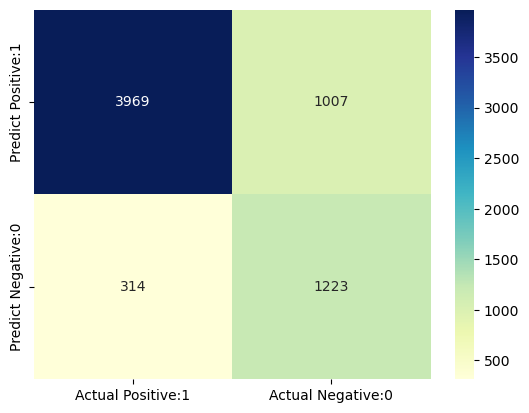

In [106]:
cm_matrix = pd.DataFrame(data=cm, columns=['Actual Positive:1', 'Actual Negative:0'], 
                                 index=['Predict Positive:1', 'Predict Negative:0'])

sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='YlGnBu')

In [107]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       <=50K       0.93      0.80      0.86      4976
        >50K       0.55      0.80      0.65      1537

    accuracy                           0.80      6513
   macro avg       0.74      0.80      0.75      6513
weighted avg       0.84      0.80      0.81      6513



In [109]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

classification_error = (FP + FN) / float(TP + TN + FP + FN)
print('Classification error : {0:0.4f}'.format(classification_error))

Classification error : 0.2028


In [110]:
y_pred_prob = gnb.predict_proba(X_test)[0:10]

y_pred_prob

array([[9.27491926e-01, 7.25080737e-02],
       [9.99999894e-01, 1.05924475e-07],
       [8.02855493e-01, 1.97144507e-01],
       [9.99992161e-01, 7.83912008e-06],
       [9.99999997e-01, 2.77357998e-09],
       [9.99999954e-01, 4.59998819e-08],
       [9.99841460e-01, 1.58540042e-04],
       [9.45200508e-01, 5.47994917e-02],
       [2.20642982e-04, 9.99779357e-01],
       [9.99999998e-01, 2.11320429e-09]])

In [111]:
y_pred_prob_df = pd.DataFrame(data=y_pred_prob, columns=['Prob of - <=50K', 'Prob of - >50K'])
y_pred_prob_df

,Prob of - <=50K,Prob of - >50K
0,0.927492,7.250807e-02
1,1.000000,1.059245e-07
2,0.802855,1.971445e-01
3,0.999992,7.839120e-06
4,1.000000,2.773580e-09
5,1.000000,4.599988e-08
6,0.999841,1.585400e-04
7,0.945201,5.479949e-02
8,0.000221,9.997794e-01
9,1.000000,2.113204e-09


In [113]:
gnb.predict_proba(X_test)[0:10, 1]
y_pred1 = gnb.predict_proba(X_test)[:, 1]

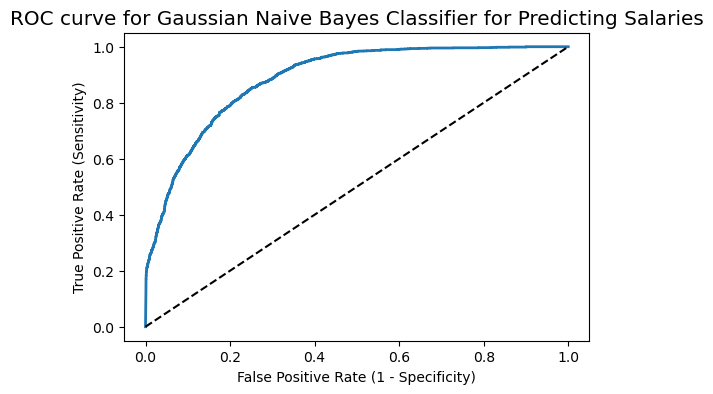

In [114]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt # Assuming matplotlib is needed, which is standard for plotting

fpr, tpr, thresholds = roc_curve(y_test, y_pred1, pos_label = '>50K')

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, linewidth=2)
plt.plot([0,1], [0,1], 'k--' )
plt.rcParams['font.size'] = 12
plt.title('ROC curve for Gaussian Naive Bayes Classifier for Predicting Salaries')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.show()